::: {.thesis-hero-wrap}
<img src="images/r-timing.svg" alt="Stopwatch alongside a five-step R pipeline diagram: Load Data, Preprocess, Train Model, Predict, Save Output" class="thesis-hero-art"/>

::: {.thesis-hero-caption}
The pipeline this tutorial times, step by step -- and, at the end, a real chart of where the time actually went.
:::
:::

::: {.tag-row}
[R]{.tag} [system.time]{.tag} [Benchmarking]{.tag} [Performance]{.tag}
:::

When working with R, it is often important to understand how long different parts of your code take to execute. This becomes especially relevant when working with large datasets, building models, or optimizing pipelines.

R provides simple tools like `system.time()`, but in practice, we often need a more structured way to measure execution time across multiple steps in a workflow.

In this tutorial, we will build a small reusable timing framework in R that allows us to:

- Measure execution time for individual steps
- Track progress in a pipeline
- Keep the code clean and readable

We will demonstrate this using a simple workflow: data generation, preprocessing, and model training.

In [1]:
# timed_pipeline.R

cat("===== R Script Execution Started =====\n")
cat("Start time:", format(Sys.time()), "\n\n")

# ----------- Helper Function to Time Each Block -----------
# `timings` collects each step's elapsed time as we go, so we can
# chart it afterwards instead of just printing it.
timings <- list()

time_it <- function(expr, label = "") {
  time <- system.time(result <- eval(expr))
  elapsed <- as.numeric(time["elapsed"])
  timings[[label]] <<- elapsed
  cat(sprintf(">>> '%s' took %.3f seconds\n", label, elapsed))
  return(result)
}

# ----------- 1. Load or Generate Data -----------
load_data <- function(n = 1000000) {
  set.seed(42)
  data.frame(
    id = 1:n,
    feature1 = rnorm(n),
    feature2 = runif(n),
    target = sample(0:1, n, replace = TRUE)
  )
}

cat("Step 1: Loading data...\n")
df <- time_it(quote(load_data()), "Load Data")

# ----------- 2. Preprocess Data -----------
preprocess_data <- function(data) {
  data$feature1_scaled <- scale(data$feature1)
  data$feature2_scaled <- scale(data$feature2)
  data
}

cat("\nStep 2: Preprocessing data...\n")
df_processed <- time_it(quote(preprocess_data(df)), "Preprocess Data")

# ----------- 3. Train a Simple Model -----------
train_model <- function(data) {
  model <- glm(target ~ feature1_scaled + feature2_scaled, data = data, family = "binomial")
  return(model)
}

cat("\nStep 3: Training model...\n")
model <- time_it(quote(train_model(df_processed)), "Train Model")

# ----------- 4. Make Predictions -----------
predict_model <- function(model, data) {
  probs <- predict(model, newdata = data, type = "response")
  data$predicted_class <- ifelse(probs > 0.5, 1, 0)
  return(data)
}

cat("\nStep 4: Making predictions...\n")
df_predicted <- time_it(quote(predict_model(model, df_processed)), "Predict")

# ----------- 5. Save Results -----------
save_results <- function(data, path = "output.csv") {
  write.csv(data, path, row.names = FALSE)
}

cat("\nStep 5: Saving output to file...\n")
time_it(quote(save_results(df_predicted)), "Save Output")

cat("\n===== R Script Execution Completed =====\n")
cat("End time:", format(Sys.time()), "\n")


===== R Script Execution Started =====


Start time: 2026-07-30 17:41:21 



Step 1: Loading data...


>>> 'Load Data' took 0.163 seconds



Step 2: Preprocessing data...


...


Step 5: Saving output to file...


>>> 'Save Output' took 3.115 seconds


NULL


===== R Script Execution Completed =====


End time: 2026-07-30 17:41:29 


## Visualizing Where the Time Went

Printed timings are useful, but a chart makes it immediate: which step actually dominates the run? The `timings` list collected above already has the real numbers from this exact execution -- no need to re-type them.

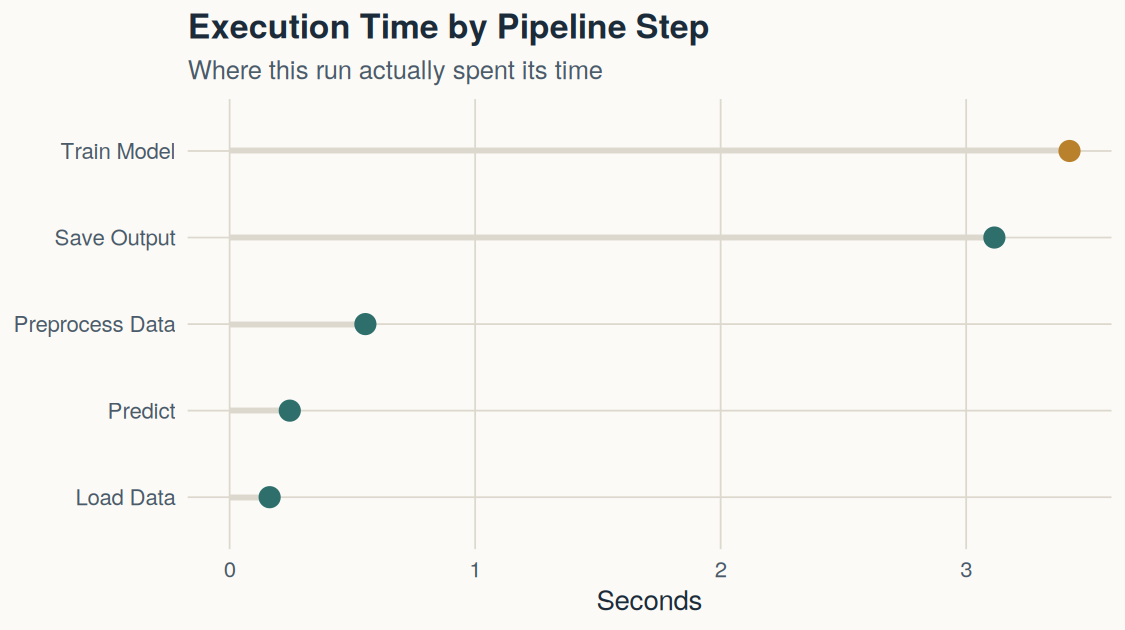

In [2]:
library(ggplot2)

options(repr.plot.width = 7.5, repr.plot.height = 4.2, repr.plot.res = 150)

theme_site <- function(base_size = 13) {
  theme_minimal(base_size = base_size) +
    theme(
      panel.background = element_rect(fill = "#fbfaf7", color = NA),
      plot.background  = element_rect(fill = "#fbfaf7", color = NA),
      panel.grid.major = element_line(color = "#ddd8cd", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      plot.title    = element_text(color = "#1c2b39", face = "bold", size = base_size + 3),
      plot.subtitle = element_text(color = "#4a5a68", size = base_size - 1),
      axis.text  = element_text(color = "#4a5a68"),
      axis.title = element_text(color = "#1c2b39"),
      legend.position = "none"
    )
}

timing_df <- data.frame(
  step = names(timings),
  seconds = unlist(timings)
)
timing_df$step <- factor(timing_df$step, levels = timing_df$step[order(timing_df$seconds)])
timing_df$is_slowest <- timing_df$seconds == max(timing_df$seconds)

ggplot(timing_df, aes(x = seconds, y = step)) +
  geom_segment(aes(x = 0, xend = seconds, y = step, yend = step), color = "#ddd8cd", linewidth = 1) +
  geom_point(aes(color = is_slowest), size = 4) +
  scale_color_manual(values = c(`TRUE` = "#b9812c", `FALSE` = "#2f6f6b")) +
  labs(
    title = "Execution Time by Pipeline Step",
    subtitle = "Where this run actually spent its time",
    x = "Seconds", y = NULL
  ) +
  theme_site()

The slowest step will vary run to run and machine to machine -- that's the point of measuring rather than guessing. On this run, writing the output file rivals or exceeds model training itself, which is easy to miss when you're only watching the console scroll by.